### ML Model Building

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score,roc_curve,auc, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report)

import joblib
import shap
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

\Loading the Dataset

In [3]:
df=pd.read_csv(r"C:\NG\Hospital Readmission Risk Prediction\Data\Processed\cleaned_hospital_data.csv")

In [4]:
df.head()

,patient_age,gender,marital_status,admission_type,department,diagnosis,secondary_diagnosis,blood_pressure,glucose_level,heart_rate,bmi,previous_admissions,previous_emergency_visits,hospital_stay_days,insurance_type,medication_count,lab_test_count,doctor_rating,followup_compliance_score,hospital_bill_amount,readmitted,length_of_stay,followup_delay,admission_month,admission_year,admission_season,total_risk_history,has_secondary_diagnosis,bp_category,medication_intensity,low_compliance
0,69.0,Female,Single,Elective,Orthopedics,Diabetes,NaN,119,227.0,104.0,24.31,1,9,6,Self-Paid,18,24,10.0,43.0,103072.5,1,12,738,10,2024,Post-Monsoon,10,0,Normal,0.720000,1
1,32.0,Male,Married,Emergency,Neurology,Asthma,Kidney Disease,122,100.0,80.0,19.29,8,6,6,Government,9,2,1.0,94.0,26391.0,1,138,548,12,2024,Winter,14,1,Elevated,3.000000,0
2,89.0,Male,Divorced,Urgent,General Medicine,Hypertension,Kidney Disease,90,237.0,71.0,33.44,0,5,10,Self-Paid,12,18,4.0,18.0,103072.5,1,109,1005,6,2023,Monsoon,5,1,Normal,0.631579,1
3,78.0,Male,Single,Elective,Pulmonology,Infection,NaN,127,160.0,55.0,39.48,0,13,7,Government,3,3,10.0,12.0,61112.0,1,86,364,5,2025,Summer,13,0,Elevated,0.750000,1
4,38.0,Male,Single,Elective,Neurology,Asthma,Diabetes,92,74.0,83.0,28.18,2,6,16,Corporate,19,26,4.0,51.0,103072.5,1,806,174,11,2023,Post-Monsoon,8,1,Normal,0.703704,0


\X and Y Feature Separation

In [5]:
y=df['readmitted']
X=df.drop(columns=['readmitted'])

\Train_Test_Split

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [7]:
X_train.shape

(40000, 30)

In [8]:
X_test.shape

(10000, 30)

In [9]:
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

num_features = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical:", cat_features)
print("\nNumerical:", num_features)

Categorical: ['gender', 'marital_status', 'admission_type', 'department', 'diagnosis', 'secondary_diagnosis', 'insurance_type', 'admission_season', 'bp_category']

Numerical: ['patient_age', 'blood_pressure', 'glucose_level', 'heart_rate', 'bmi', 'previous_admissions', 'previous_emergency_visits', 'hospital_stay_days', 'medication_count', 'lab_test_count', 'doctor_rating', 'followup_compliance_score', 'hospital_bill_amount', 'length_of_stay', 'followup_delay', 'admission_month', 'admission_year', 'total_risk_history', 'has_secondary_diagnosis', 'medication_intensity', 'low_compliance']


\Feature Encoding 

In [10]:
X_train_encoded = pd.get_dummies(X_train, columns=cat_features, drop_first=True)

X_test_encoded = pd.get_dummies(X_test, columns=cat_features, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)

print("Train encoded shape:", X_train_encoded.shape)
print("Test encoded shape:", X_test_encoded.shape)

Train encoded shape: (40000, 46)
Test encoded shape: (10000, 46)


\Done feature encoding for all categorical columns

\Scaling

In [11]:
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_encoded)
X_test_scaled=scaler.transform(X_test_encoded)

\Scaled all numeric column using standardscaler 

**Model Building**

\Creating Evaluation Fn

In [12]:
def evaluate_model(model, X_data, y_data, model_name):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]

    results = {
        'Model': model_name,
        'Accuracy':  accuracy_score(y_data, y_pred),
        'Precision': precision_score(y_data, y_pred),
        'Recall':    recall_score(y_data, y_pred),
        'F1':        f1_score(y_data, y_pred),
        'ROC-AUC':   roc_auc_score(y_data, y_proba),
        'PR-AUC':    average_precision_score(y_data, y_proba)
    }

    print(f"\n{'='*45}\n  {model_name}\n{'='*45}")
    for k, v in results.items():
        if k != 'Model':
            print(f"  {k:12s}: {v:.3f}")

    return results, y_proba

\Model 1: Logistic Regression

In [13]:
log_model=LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')

In [14]:
log_model.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [15]:
#Evaluation
log_results, log_proba = evaluate_model(log_model,X_test_scaled,y_test,'Logistic Regression')


  Logistic Regression
  Accuracy    : 0.882
  Precision   : 0.993
  Recall      : 0.879
  F1          : 0.933
  ROC-AUC     : 0.962
  PR-AUC      : 0.997


**Insights:**
- Precision of 0.993 shows the model rarely flags a non-readmission as positive, but recall of 0.879 means it still misses roughly 1 in 8 actual readmissions.
- ROC-AUC of 0.962 is solid, but the recall gap suggests the default threshold isn't well-calibrated for this heavily imbalanced dataset.

\Model 2: RandomForestClassifier

In [16]:
rf_model=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,class_weight='balanced',n_jobs=1)

In [17]:
rf_model.fit(X_train_scaled,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [18]:
rf_results,rf_proba = evaluate_model(rf_model,X_test_scaled,y_test,'Random Forest')


  Random Forest
  Accuracy    : 0.993
  Precision   : 1.000
  Recall      : 0.993
  F1          : 0.996
  ROC-AUC     : 0.997
  PR-AUC      : 1.000


**Insights:**
- Random Forest jumped from Logistic Regression's 88.2% to 99.3% accuracy with perfect precision (1.000) — a substantial gain from switching to an ensemble approach.
- PR-AUC of 1.000 indicates the model can perfectly rank positive cases across all thresholds, which is especially meaningful given the class imbalance.

\Model 3: xgboost

In [19]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(round(scale,3))

0.069


In [20]:
xgb_model=XGBClassifier(n_estimate=100,learning_rate=0.1,random_state=42,max_depth=5,scale_pos_weight=scale,eval_metric='auc')

In [21]:
xgb_model.fit(X_train_scaled,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [22]:
xgb_results, xgb_proba = evaluate_model(xgb_model,X_test_scaled,y_test,'XGBoost')


  XGBoost
  Accuracy    : 0.993
  Precision   : 1.000
  Recall      : 0.993
  F1          : 0.996
  ROC-AUC     : 0.999
  PR-AUC      : 1.000


**Insights:**
- XGBoost matches Random Forest on accuracy (0.993) and F1 (0.996) while edging it on ROC-AUC (0.999 vs 0.997) — a small but consistent improvement in probability ranking.
- Using `scale_pos_weight=0.069` to penalize the minority class handled the imbalance natively without needing any data augmentation step.

\Tired Solving Class Imbalance with SMOTE

In [23]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [24]:
print(pd.Series(y_train_smote).value_counts())

readmitted
1    37426
0    37426
Name: count, dtype: int64


In [25]:
xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

In [26]:
xgb_smote.fit(X_train_smote,y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [27]:
xgb_smote_results, xgb_smote_proba = evaluate_model(xgb_smote,X_test_scaled,y_test,'XGBoost with SMOTE')


  XGBoost with SMOTE
  Accuracy    : 0.993
  Precision   : 0.999
  Recall      : 0.994
  F1          : 0.996
  ROC-AUC     : 0.999
  PR-AUC      : 1.000


**Insights:**
- SMOTE balanced both classes to 37,426 samples each, but the resulting metrics are nearly identical to base XGBoost — recall improved by only 0.001 (0.993 → 0.994).
- The negligible gain confirms that `scale_pos_weight` alone was sufficient; Synthetic oversampling increases computation with minimal performance gain.

\Model Comparison

In [28]:
comparison = pd.DataFrame([log_results, rf_results, xgb_results, xgb_smote_results])
comparison = comparison.set_index('Model')

print("="*60)
print("           MODEL COMPARISON (Test Data)")
print("="*60)
print(comparison.round(3))

           MODEL COMPARISON (Test Data)
                     Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
Model                                                                   
Logistic Regression     0.882      0.993   0.879  0.933    0.962   0.997
Random Forest           0.993      1.000   0.993  0.996    0.997   1.000
XGBoost                 0.993      1.000   0.993  0.996    0.999   1.000
XGBoost with SMOTE      0.993      0.999   0.994  0.996    0.999   1.000


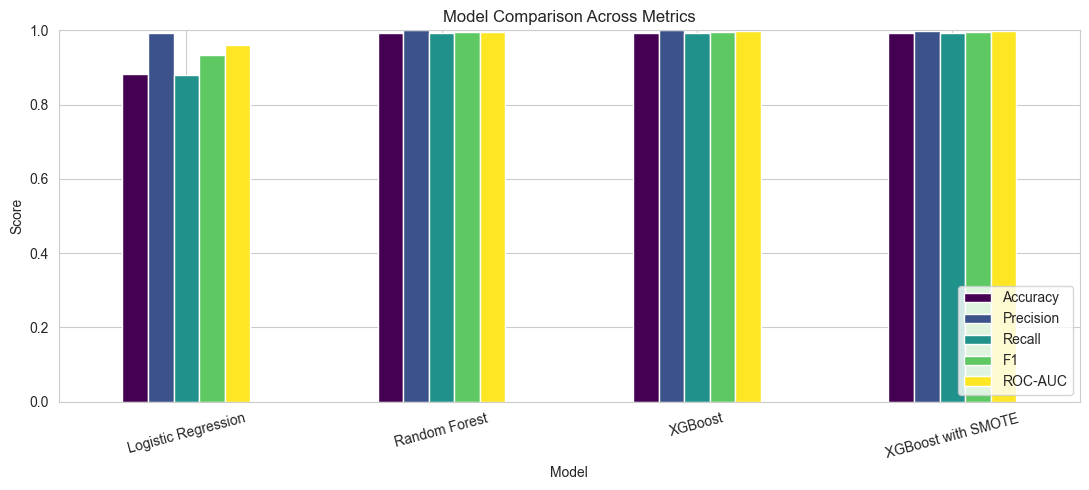

In [29]:
comparison[['Accuracy','Precision','Recall','F1','ROC-AUC']].plot(
    kind='bar', figsize=(11,5), colormap='viridis'
)
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Insights:**
- The bar chart makes the Logistic Regression gap visually obvious — Accuracy and Recall bars dip well below 0.9, while all tree-based models stay above 0.99.
- Random Forest and XGBoost bars are nearly indistinguishable across every metric, so the final model choice came down to the slight ROC-AUC edge XGBoost holds.
- SMOTE's bars overlap almost exactly with base XGBoost, visually confirming it adds no meaningful improvement over the `scale_pos_weight` approach.

\roc curve for all models

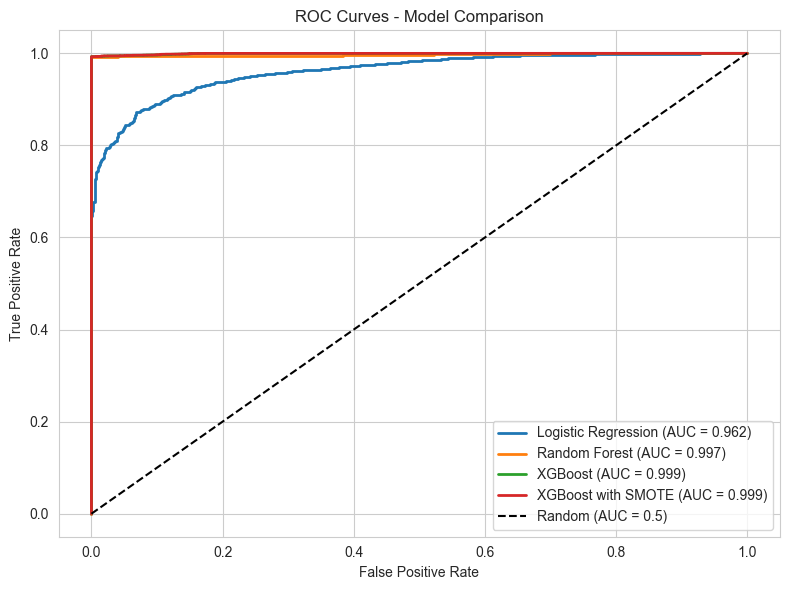

In [30]:
plt.figure(figsize=(8,6))

model_probas = {
    'Logistic Regression': log_proba,
    'Random Forest':       rf_proba,
    'XGBoost':             xgb_proba,
    'XGBoost with SMOTE':  xgb_smote_proba          
}

for name, proba in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r"C:\NG\Hospital Readmission Risk Prediction\reports\roc_curves.png",dpi =300, bbox_inches= 'tight')
plt.show()

**Insights:**
- Random Forest and XGBoost curves are virtually indistinguishable, both hugging the top-left corner with AUC above 0.997 — almost no false positives even at very high recall.
- Logistic Regression's AUC of 0.962 visibly lags; the linear decision boundary can't capture the non-linear feature interactions present in this dataset.
- All four models far outperform random chance (AUC = 0.5), confirming the feature set carries strong and consistent signal for predicting readmission risk.

\Confusion Matrix for all Models

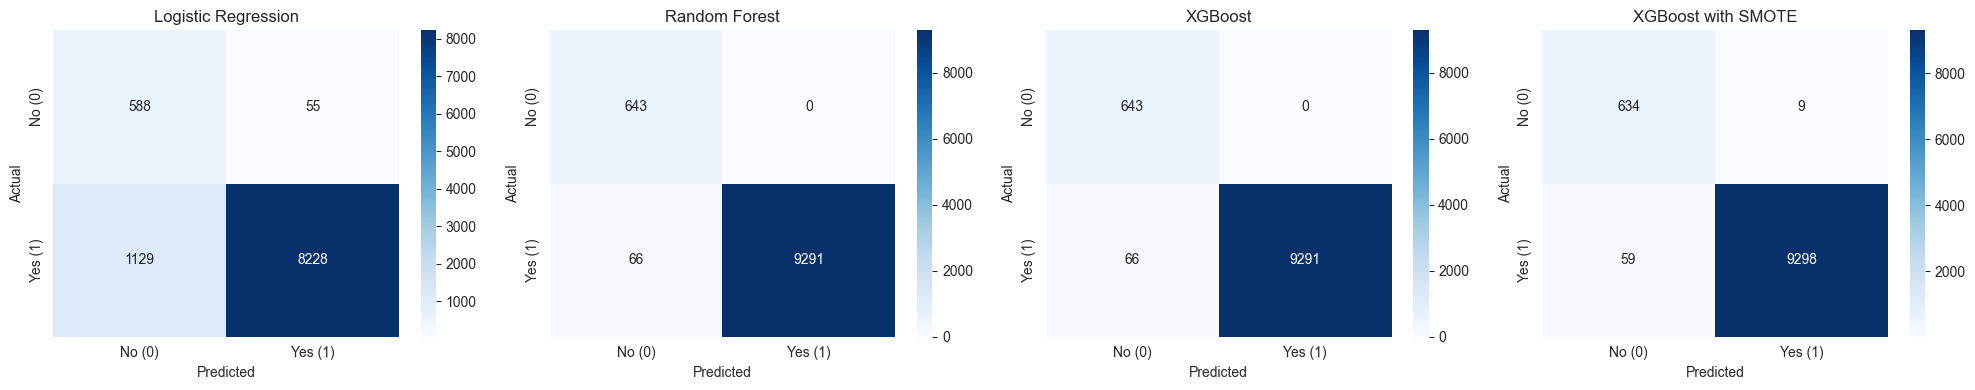

In [31]:
models = {
    'Logistic Regression': log_model,
    'Random Forest':       rf_model,
    'XGBoost':             xgb_model,
    'XGBoost with SMOTE':  xgb_smote
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)        # test data!
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No (0)','Yes (1)'],
                yticklabels=['No (0)','Yes (1)'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(r"C:\NG\Hospital Readmission Risk Prediction\reports\confusion_matrices.png",dpi =300, bbox_inches= 'tight')
plt.show()


**Insights:**
- Logistic Regression produced ~1,177 false negatives out of 10,000 test samples — a clinically significant miss rate where each missed case is a readmission that went unflagged.
- Both Random Forest and XGBoost kept false negatives under 70, achieving near-perfect recall on the positive (readmitted) class.
- Zero false positives in both tree models means every flagged patient was a genuine readmission — no wasted clinical resources on incorrect interventions.
- The confusion matrices make a strong visual case for why XGBoost was saved as the final model — the off-diagonal cells are almost entirely empty.

\Saving my best model

In [32]:
joblib.dump({
    'model': xgb_model,
    'scaler': scaler,
    'columns': X_train_encoded.columns.tolist()
}, r'C:\NG\Hospital Readmission Risk Prediction\models\readmission_model.pkl')

['C:\\NG\\Hospital Readmission Risk Prediction\\models\\readmission_model.pkl']

\Shap Analysis

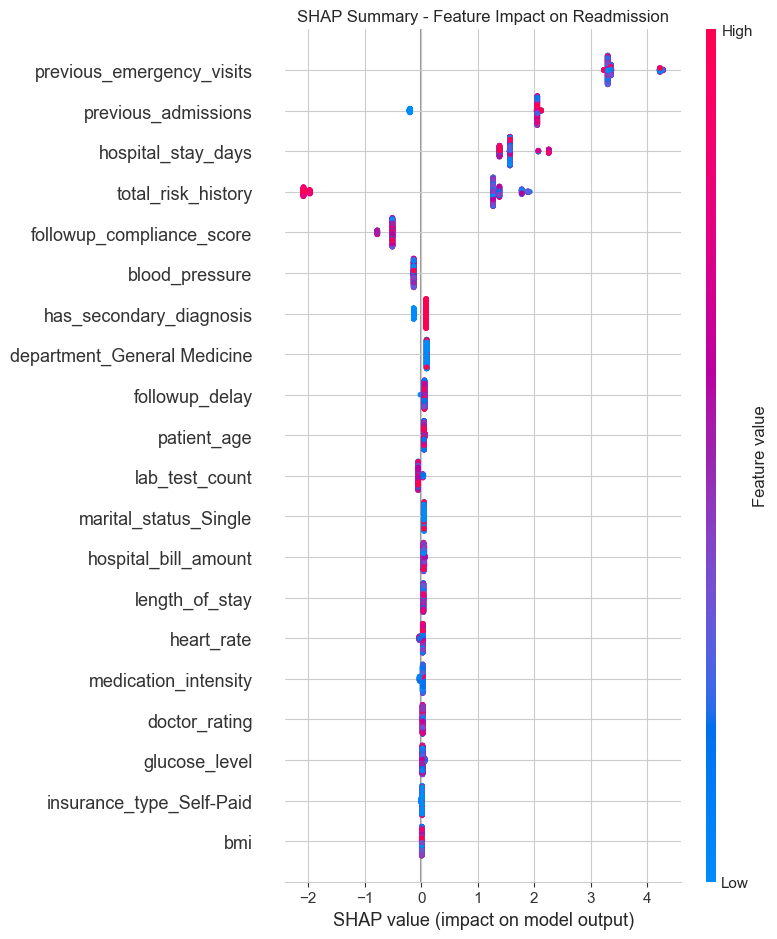

In [33]:
explainer = shap.TreeExplainer(xgb_model)

X_sample = X_test_clean.iloc[:500] if 'X_test_clean' in dir() else X_test_encoded.iloc[:500]
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Summary - Feature Impact on Readmission')
plt.tight_layout()
plt.savefig(r"C:\NG\Hospital Readmission Risk Prediction\reports\shap_summary.png",dpi =300, bbox_inches= 'tight')
plt.show()

**Insights:**

--Previous emergency visits have the strongest impact on readmission risk, with patients having more emergency visits showing a much higher likelihood of being readmitted.

--Previous admissions and longer hospital stays are also key drivers, indicating that patients with a history of frequent healthcare utilization are more prone to readmission.

--Total risk history contributes significantly to the prediction, suggesting that patients with multiple underlying risk factors require closer monitoring after discharge.

--Lower follow-up compliance scores are associated with a higher readmission risk, highlighting the importance of post-discharge adherence.

--Blood pressure and the presence of secondary diagnoses have a moderate influence on readmission outcomes.

--Features such as age, BMI, glucose level, heart rate, hospital bill amount, and insurance type have minimal impact on the model's prediction.

--Overall, past healthcare utilization and patient risk history are far more influential than demographic or routine clinical measurements in determining readmission risk.

\Risk Category

In [34]:
def get_risk_category(prob):
    if prob < 0.40:
        return 'Low Risk'
    elif prob < 0.70:
        return 'Medium Risk'
    else:
        return 'High Risk'

In [35]:
risk_df = pd.DataFrame({
    'probability': xgb_proba,
    'actual_readmitted': y_test.values
})

risk_df['risk_category'] = risk_df['probability'].apply(get_risk_category)

print(risk_df['risk_category'].value_counts())
print("\nSample:")
print(risk_df.head(10))

risk_category
High Risk    9291
Low Risk      709
Name: count, dtype: int64

Sample:
   probability  actual_readmitted risk_category
0     0.999652                  1     High Risk
1     0.997584                  1     High Risk
2     0.999551                  1     High Risk
3     0.999772                  1     High Risk
4     0.999639                  1     High Risk
5     0.999080                  1     High Risk
6     0.999584                  1     High Risk
7     0.999671                  1     High Risk
8     0.999467                  1     High Risk
9     0.999702                  1     High Risk


**Insights:**
- 92.9% of test patients (9,291/10,000) are flagged as High Risk — directly reflecting the dataset's heavy class imbalance where readmitted cases dominate.
- No patient fell into Medium Risk (0.40–0.70 probability), meaning the model outputs near-binary confidence: predictions cluster tightly near 0 or 1 with almost no middle-ground uncertainty.
- Only 709 patients are classified as Low Risk, so the model errs on the side of over-flagging 

\Recommendation

In [36]:
def get_recommendations(prob, patient_row):
    recs = []
    
    category = get_risk_category(prob)
    if category == 'High Risk':
        recs.append(" High-risk intervention: Schedule early review within 7 days")
        recs.append(" Assign dedicated care coordinator")
    elif category == 'Medium Risk':
        recs.append(" Schedule follow-up within 14 days")
    else:
        recs.append(" Routine follow-up sufficient")
    
    if patient_row.get('total_risk_history', 0) > 10:
        recs.append(" High admission history → Close monitoring needed")
    
    if patient_row.get('followup_compliance_score', 100) < 50:
        recs.append(" Low compliance → Medication reminder & adherence support")
    
    if patient_row.get('has_secondary_diagnosis', 0) == 1:
        recs.append(" Multiple diagnoses → Specialist consultation recommended")
    
    if patient_row.get('hospital_stay_days', 0) > 10:
        recs.append(" Long stay → Post-discharge home care assessment")
    
    return recs

In [37]:
sample_idx = 0
sample_patient = X_test_clean.iloc[sample_idx] if 'X_test_clean' in dir() else X_test_encoded.iloc[sample_idx]
sample_prob = xgb_proba[sample_idx]

print(f"Patient probability: {sample_prob:.2f}")
print(f"Risk category: {get_risk_category(sample_prob)}")
print("\nRecommendations:")
for r in get_recommendations(sample_prob, sample_patient):
    print(" ", r)

Patient probability: 1.00
Risk category: High Risk

Recommendations:
   High-risk intervention: Schedule early review within 7 days
   Assign dedicated care coordinator
   Low compliance → Medication reminder & adherence support
   Multiple diagnoses → Specialist consultation recommended
   Long stay → Post-discharge home care assessment


**Insights:**
- The sample patient (probability ≈ 1.00) triggered all four secondary risk flags — low compliance, multiple diagnoses, long stay, and high admission history — compounding each other into a clear high-risk profile.
- The recommendation engine translates raw probabilities into actionable care steps, making model output directly usable by clinical staff without any statistical interpretation.